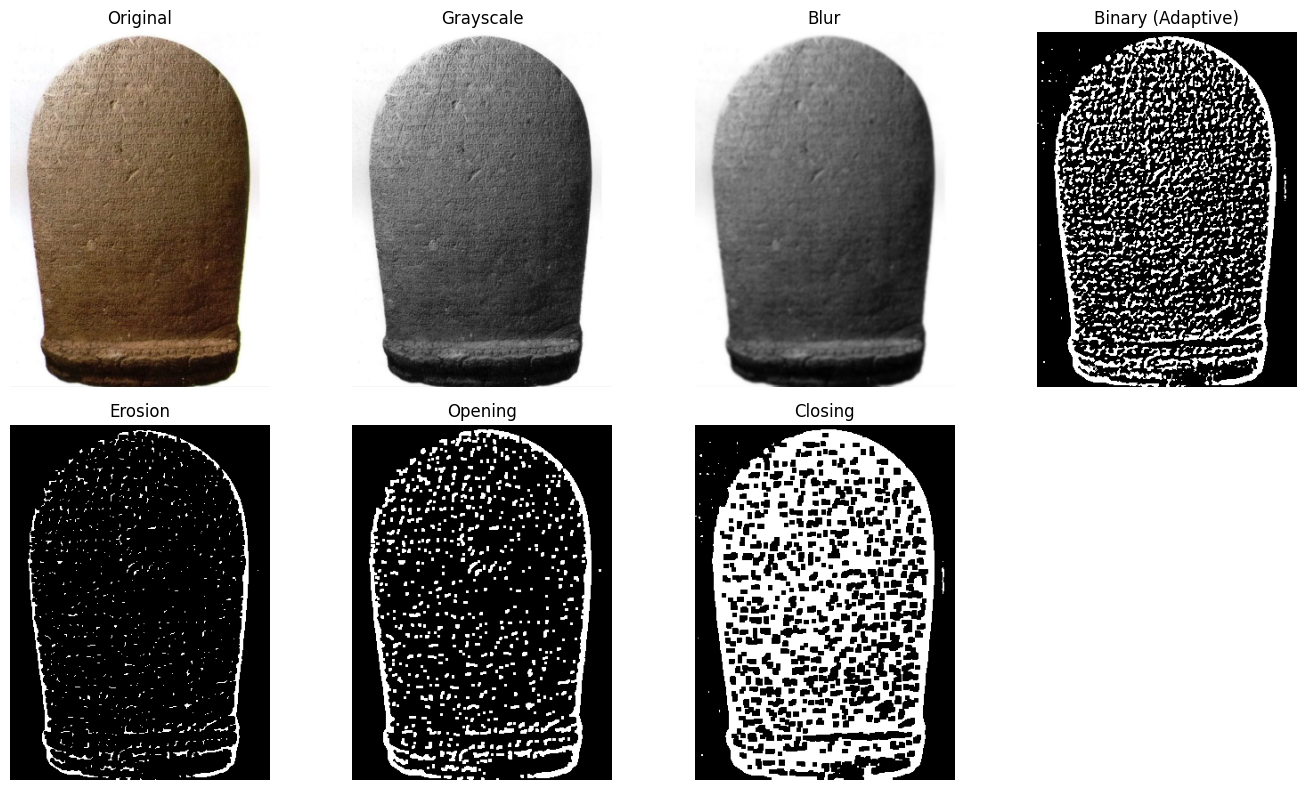

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# =========================
# 1. Load Image
# =========================
image_path = 's_aksara_jawa.png'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# 2. Grayscale
# =========================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =========================
# 3. Blur (hilangkan noise halus)
# =========================
blur = cv2.GaussianBlur(gray, (5,5), 0)

# =========================
# 4. Adaptive Threshold (LEBIH BAGUS dari threshold biasa)
# =========================
binary = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15,   # block size (ganjil)
    3     # konstanta
)

# =========================
# 5. Kernel (lebih realistis)
# =========================
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# =========================
# 6. EROSI
# =========================
erosi = cv2.erode(binary, kernel, iterations=1)

# =========================
# 7. OPENING (bersihin noise kecil)
# =========================
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# =========================
# 8. CLOSING (nutup celah tulisan)
# =========================
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# =========================
# 9. Visualisasi
# =========================
titles = [
    'Original',
    'Grayscale',
    'Blur',
    'Binary (Adaptive)',
    'Erosion',
    'Opening',
    'Closing'
]

images = [
    img_rgb,
    gray,
    blur,
    binary,
    erosi,
    opening,
    closing
]

plt.figure(figsize=(14,8))

for i in range(len(images)):
    plt.subplot(2,4,i+1)
    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()